# HRC -I  background event files

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 144/
download_chandra_obsid 144 evt2,asol


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  evt2     fits       27 Mb  ####################          < 1 s  73988.5 kb/s
  asol     fits        8 Mb  ####################          < 1 s  65169.0 kb/s

      Total download size for ObsId 144 = 35 Mb
      Total download time for ObsId 144 = < 1 s



## Naming scheme

In [3]:
ls -1 $CALDB/data/chandra/hrc/bkgrnd/

README.txt
hrc_bkgrnd_manifest.txt
hrciD2000-01-01bkgrndN0002.fits
hrciD2001-01-01bkgrndN0002.fits
hrciD2002-01-01bkgrndN0002.fits
hrciD2003-01-01bkgrndN0002.fits
hrciD2004-01-01bkgrndN0002.fits
hrciD2005-01-01bkgrndN0002.fits
hrciD2006-01-01bkgrndN0002.fits
hrciD2007-01-01bkgrndN0002.fits
hrciD2008-01-01bkgrndN0002.fits
hrciD2009-01-01bkgrndN0002.fits
hrciD2010-01-01bkgrndN0002.fits
hrciD2011-01-01bkgrndN0002.fits
hrciD2012-01-01bkgrndN0002.fits
hrciD2013-01-01bkgrndN0002.fits
hrciD2014-01-01bkgrndN0002.fits
hrciD2015-01-01bkgrndN0002.fits


## Using lookup

In [4]:
hrc_bkgrnd_lookup 144/primary/hrcf00144N007_evt2.fits event

/export/ciao-4.9/CALDB/data/chandra/hrc/bkgrnd/hrciD2000-01-01bkgrndN0002.fits


In [5]:
dmkeypar 144/primary/hrcf00144N007_evt2.fits DATE-OBS echo+

2000-09-01T00:13:35


In [6]:
pget hrc_bkgrnd_lookup outfile

/export/ciao-4.9/CALDB/data/chandra/hrc/bkgrnd/hrciD2000-01-01bkgrndN0002.fits


## Make local copy

In [7]:
cp -fv \
    $CALDB/data/chandra/hrc/bkgrnd/hrciD2000-01-01bkgrndN0002.fits \
    144_bg.fits


`/export/ciao-4.9/CALDB/data/chandra/hrc/bkgrnd/hrciD2000-01-01bkgrndN0002.fits' -> `144_bg.fits'


In [8]:
chmod +w 144_bg.fits

## Tailor files


### Add `PNT` keywords

In [9]:
dmlist 144_bg.fits header |grep PNT

0071 RA_PNT                                  0           Real8        Pointing RA
0072 DEC_PNT                                 0           Real8        Pointing Dec
0073 ROLL_PNT                                0           Real8        Pointing Roll


In [10]:
dmmakepar 144/primary/hrcf00144N007_evt2.fits event_header.par cl+

In [11]:
grep _pnt event_header.par | tee event_pnt.par

ra_pnt,r,h,278.38757870031,,,"Pointing RA [deg]"
dec_pnt,r,h,-10.572477395455,,,"Pointing Dec [deg]"
roll_pnt,r,h,266.26429513558,,,"Pointing Roll [deg]"


In [12]:
dmreadpar event_pnt.par "144_bg.fits[events]" clobber+

In [13]:
dmlist 144_bg.fits header |grep PNT

0071 RA_PNT                     278.3875787003           Real8        Pointing RA [deg]
0072 DEC_PNT                    -10.5724773955           Real8        Pointing Dec [deg]
0073 ROLL_PNT                   266.2642951356           Real8        Pointing Roll [deg]


### Apply status filter

In [14]:
dmhistory 144/primary/hrcf00144N007_evt2.fits dmcopy

# dmhistory (CIAO 4.9): WARNING: Found and corrected "pixlib" library parameters

dmcopy infile="/dsops/rsap/ap/sdp.29/opus/prs_run/tmp//HRC_L2____465743581n950/output/tmpf00144N007_evt2.fits[status=xxxxxx00xxxx0xxx00000000x0000000]" outfile="/dsops/rsap/ap/sdp.29/opus/prs_run/tmp//HRC_L2____465743581n950/output/hrcf00144N007_evt2.fits" kernel="default" option="" verbose="0" clobber="no" 



In [15]:
dmcopy "144_bg.fits[status=xxxxxx00xxxx0xxx00000000x0000000]" \
       144_filt_bg.fits clob+

### Reproject 

In [16]:
pset reproject_events infile=144_filt_bg.fits
pset reproject_events outfile=144_reproj_bg.fits
pset reproject_events aspect=144/primary/pcadf084154631N006_asol1.fits
pset reproject_events match=144/primary/hrcf00144N007_evt2.fits
pset reproject_events random=0
reproject_events mode=h clo+

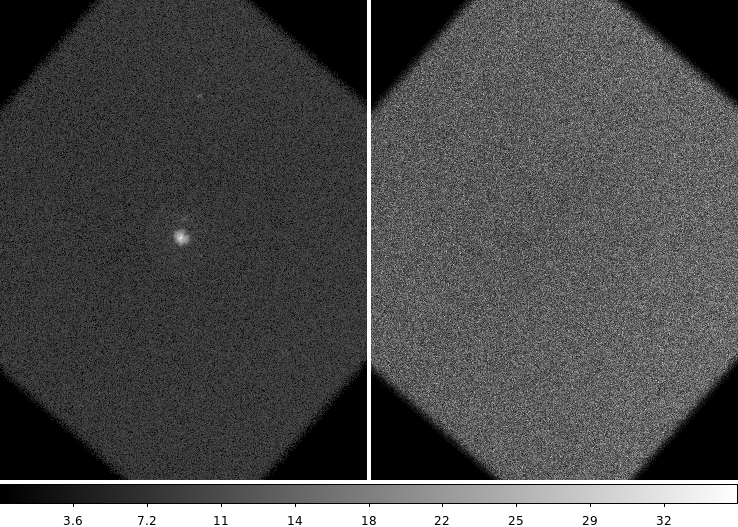

In [17]:
ds9 144/primary/hrcf00144N007_evt2.fits.gz -scale log -bin factor 32 \
  144_reproj_bg.fits -scale linear -bin factor 32 \
  -saveimage png ds9.png -quit

display < ds9.png